In [16]:
# Cell 1: Google Drive mount
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# Cell 2: rasterio installation
# rasterio reads and writes georeferenced raster files (GeoTIFF)
!pip install -q rasterio

In [18]:
# Cell 3: Chip loading and inspection
from pathlib import Path
import numpy as np
import rasterio

HAND_DIR = Path("/content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/data/sen1floods11/HandLabeled")
CHIP_ID = "Bolivia_103757"

def read_layer(layer):
    """Reads one layer of the selected chip; returns the pixel array (bands, height, width) and the file metadata."""
    path = HAND_DIR / layer / f"{CHIP_ID}_{layer}.tif"
    with rasterio.open(path) as src:
        return src.read(), src.profile

s1, s1_profile = read_layer("S1Hand")
s2, s2_profile = read_layer("S2Hand")
label, label_profile = read_layer("LabelHand")

# Shape, data type and value range of each layer (NaN values are ignored in min and max)
for name, arr in [("S1", s1), ("S2", s2), ("Label", label)]:
    n_nan = int(np.isnan(arr).sum()) if arr.dtype.kind == "f" else 0
    print(f"{name}: shape={arr.shape}, dtype={arr.dtype}, min={np.nanmin(arr):.2f}, max={np.nanmax(arr):.2f}, NaN pixels={n_nan}")

# Coordinate reference system and pixel size (in the units of that system)
print("\nCRS:", s1_profile["crs"])
print("Pixel width, height:", s1_profile["transform"].a, s1_profile["transform"].e)

# Pixel count and share for each label value: -1 no data, 0 not water, 1 water
print()
values, counts = np.unique(label, return_counts=True)
for v, c in zip(values, counts):
    print(f"Label {v}: {c} pixels ({100 * c / label.size:.1f}%)")

S1: shape=(2, 512, 512), dtype=float32, min=-48.25, max=-0.69, NaN pixels=321042
S2: shape=(13, 512, 512), dtype=int16, min=0.00, max=5662.00, NaN pixels=0
Label: shape=(1, 512, 512), dtype=int16, min=-1.00, max=1.00, NaN pixels=0

CRS: EPSG:4326
Pixel width, height: 8.983152841195215e-05 -8.983152841195215e-05

Label -1: 174067 pixels (66.4%)
Label 0: 52715 pixels (20.1%)
Label 1: 35362 pixels (13.5%)


Saved: /content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/figures/stage1_Bolivia_103757.png


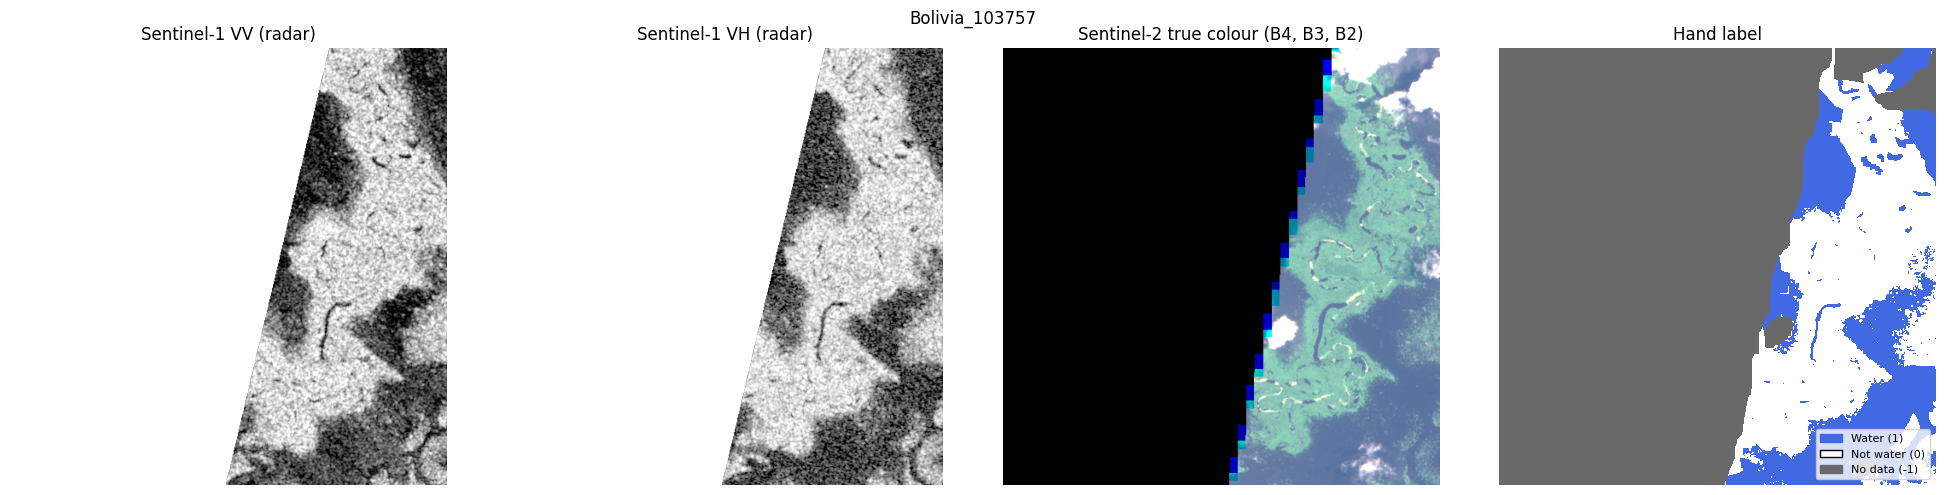

In [19]:
# Cell 4: Side-by-side view of radar, optical and label
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

FIG_DIR = Path("/content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/figures")

def stretch(band, low=2, high=98):
    """Rescales a band to the 0-1 range between its 2nd and 98th percentiles; NaN values are ignored. Display only."""
    band = band.astype("float32")
    lo, hi = np.nanpercentile(band, [low, high])
    return np.clip((band - lo) / (hi - lo), 0, 1)

# Sentinel-2 true colour composite: B4 (red), B3 (green), B2 (blue) at band indices 3, 2, 1
rgb = np.dstack([stretch(s2[i]) for i in (3, 2, 1)])

# Label colours in value order: -1 no data, 0 not water, 1 water
label_cmap = ListedColormap(["dimgrey", "white", "royalblue"])

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(stretch(s1[0]), cmap="gray")
axes[0].set_title("Sentinel-1 VV (radar)")

axes[1].imshow(stretch(s1[1]), cmap="gray")
axes[1].set_title("Sentinel-1 VH (radar)")

axes[2].imshow(rgb)
axes[2].set_title("Sentinel-2 true colour (B4, B3, B2)")

axes[3].imshow(label[0], cmap=label_cmap, vmin=-1, vmax=1, interpolation="nearest")
axes[3].set_title("Hand label")
axes[3].legend(
    handles=[Patch(color="royalblue", label="Water (1)"),
             Patch(facecolor="white", edgecolor="black", label="Not water (0)"),
             Patch(color="dimgrey", label="No data (-1)")],
    loc="lower right", fontsize=8,
)

for ax in axes:
    ax.axis("off")

fig.suptitle(CHIP_ID)
plt.tight_layout()

# Figure saved to Drive before display
out_path = FIG_DIR / f"stage1_{CHIP_ID}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("Saved:", out_path)
plt.show()

In [20]:
# Cell 5: Label statistics for all 446 chips
import pandas as pd

STATS_PATH = Path("/content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/results/stage1_label_stats.csv")

# Per-chip shares: no-data share of the whole chip, water share among valid (non -1) pixels only
rows = []
for path in sorted((HAND_DIR / "LabelHand").glob("*.tif")):
    with rasterio.open(path) as src:
        lab = src.read(1)
    valid = int((lab != -1).sum())
    water = int((lab == 1).sum())
    chip_id = path.name.replace("_LabelHand.tif", "")
    rows.append({
        "chip_id": chip_id,
        "event": chip_id.split("_")[0],
        "nodata_pct": 100 * float((lab == -1).mean()),
        "water_pct_of_valid": 100 * water / valid if valid > 0 else float("nan"),
    })

stats = pd.DataFrame(rows)
stats.to_csv(STATS_PATH, index=False)
print("Saved:", STATS_PATH)

# Summary per event: number of chips, mean no-data share, mean water share among valid pixels
summary = stats.groupby("event").agg(
    chips=("chip_id", "count"),
    nodata_pct_mean=("nodata_pct", "mean"),
    water_pct_mean=("water_pct_of_valid", "mean"),
).round(1)
print(summary)

Saved: /content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/results/stage1_label_stats.csv
           chips  nodata_pct_mean  water_pct_mean
event                                            
Bolivia       15             27.1            17.0
Ghana         53             33.8             7.1
India         68             16.0            12.8
Mekong        30              9.3            23.6
Nigeria       18             14.3            22.3
Pakistan      28             26.7             7.6
Paraguay      67              5.0             9.4
Somalia       26             21.1             6.2
Spain         30              1.7            14.1
Sri-Lanka     42              9.5            11.2
USA           69              2.4             4.6


Saved: /content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/figures/stage1_Bolivia_103757.png


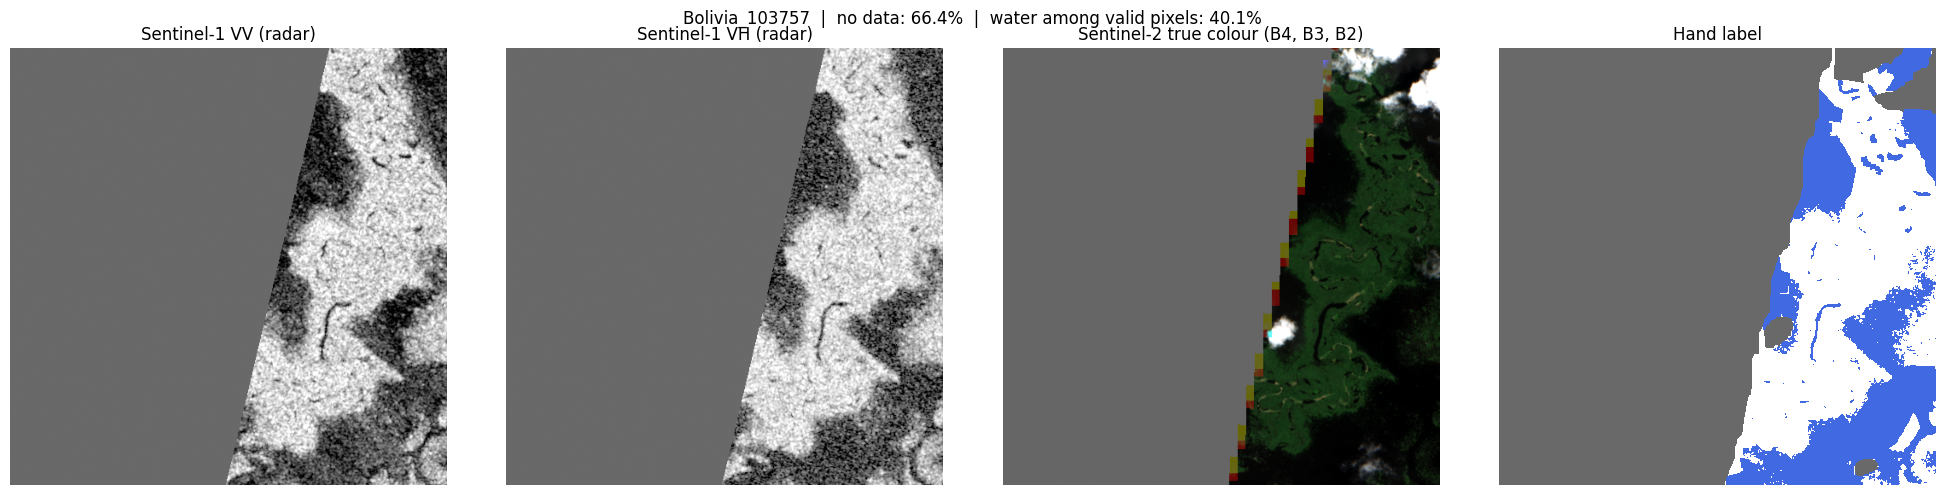

In [21]:
# Cell 6: Reusable chip viewer
def read_chip_layer(chip_id, layer):
    """Reads one layer of a chip and returns the pixel array (bands, height, width)."""
    with rasterio.open(HAND_DIR / layer / f"{chip_id}_{layer}.tif") as src:
        return src.read()

def show_chip(chip_id, save=True):
    """Draws radar VV, radar VH, Sentinel-2 true colour and the hand label for one chip.
    No-data areas are shown in grey in every panel. Optionally saves the figure to Drive."""
    s1 = read_chip_layer(chip_id, "S1Hand")
    s2 = read_chip_layer(chip_id, "S2Hand").astype("float32")
    lab = read_chip_layer(chip_id, "LabelHand")[0]

    # Sentinel-2 value 0 marks pixels without imagery; treated as NaN so the stretch ignores them
    s2[s2 == 0] = np.nan
    rgb = np.dstack([stretch(s2[i]) for i in (3, 2, 1)])
    rgb = np.where(np.isnan(rgb), 0.4, rgb)

    # Grey colour map with NaN shown in dim grey instead of white
    radar_cmap = plt.cm.gray.copy()
    radar_cmap.set_bad("dimgrey")

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(stretch(s1[0]), cmap=radar_cmap)
    axes[0].set_title("Sentinel-1 VV (radar)")
    axes[1].imshow(stretch(s1[1]), cmap=radar_cmap)
    axes[1].set_title("Sentinel-1 VH (radar)")
    axes[2].imshow(rgb)
    axes[2].set_title("Sentinel-2 true colour (B4, B3, B2)")
    axes[3].imshow(lab, cmap=label_cmap, vmin=-1, vmax=1, interpolation="nearest")
    axes[3].set_title("Hand label")

    for ax in axes:
        ax.axis("off")

    # Title with the no-data share and the water share among valid pixels
    valid = (lab != -1).sum()
    water_pct = 100 * (lab == 1).sum() / valid if valid > 0 else float("nan")
    fig.suptitle(f"{chip_id}  |  no data: {100 * (lab == -1).mean():.1f}%  |  water among valid pixels: {water_pct:.1f}%")
    plt.tight_layout()

    if save:
        out_path = FIG_DIR / f"stage1_{chip_id}.png"
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print("Saved:", out_path)
    plt.show()

# Check of the improved viewer on the same chip as before
show_chip("Bolivia_103757")



most water (under 20% no data): Sri-Lanka_534068
Saved: /content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/figures/stage1_Sri-Lanka_534068.png


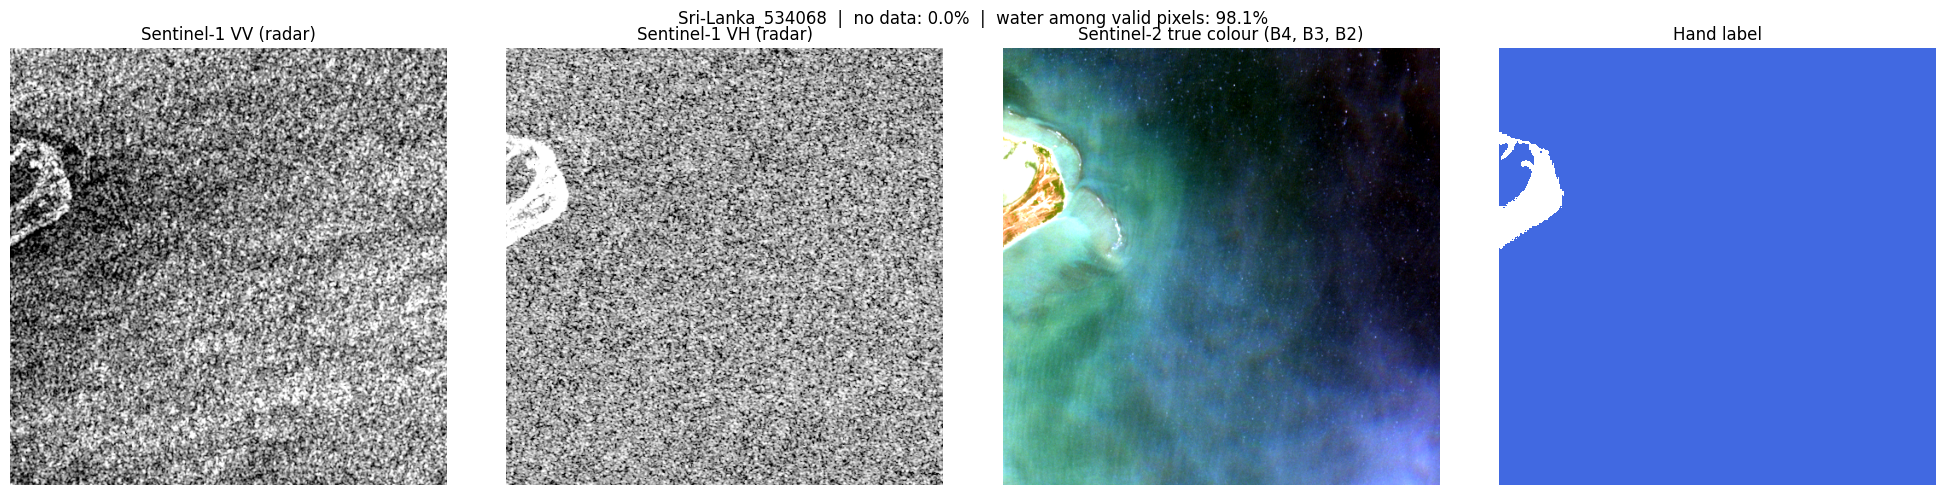


least water (under 20% no data): Ghana_124834
Saved: /content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/figures/stage1_Ghana_124834.png


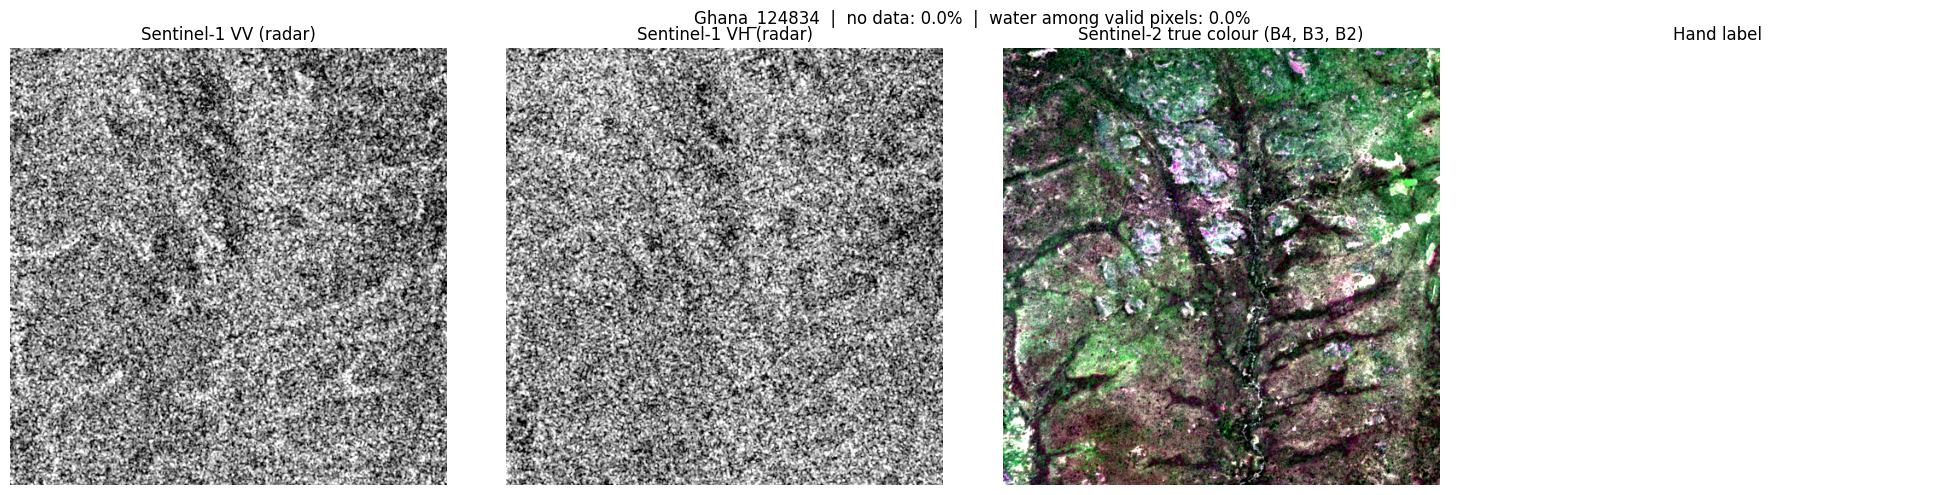


most no data (some valid pixels left): Ghana_161233
Saved: /content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/figures/stage1_Ghana_161233.png


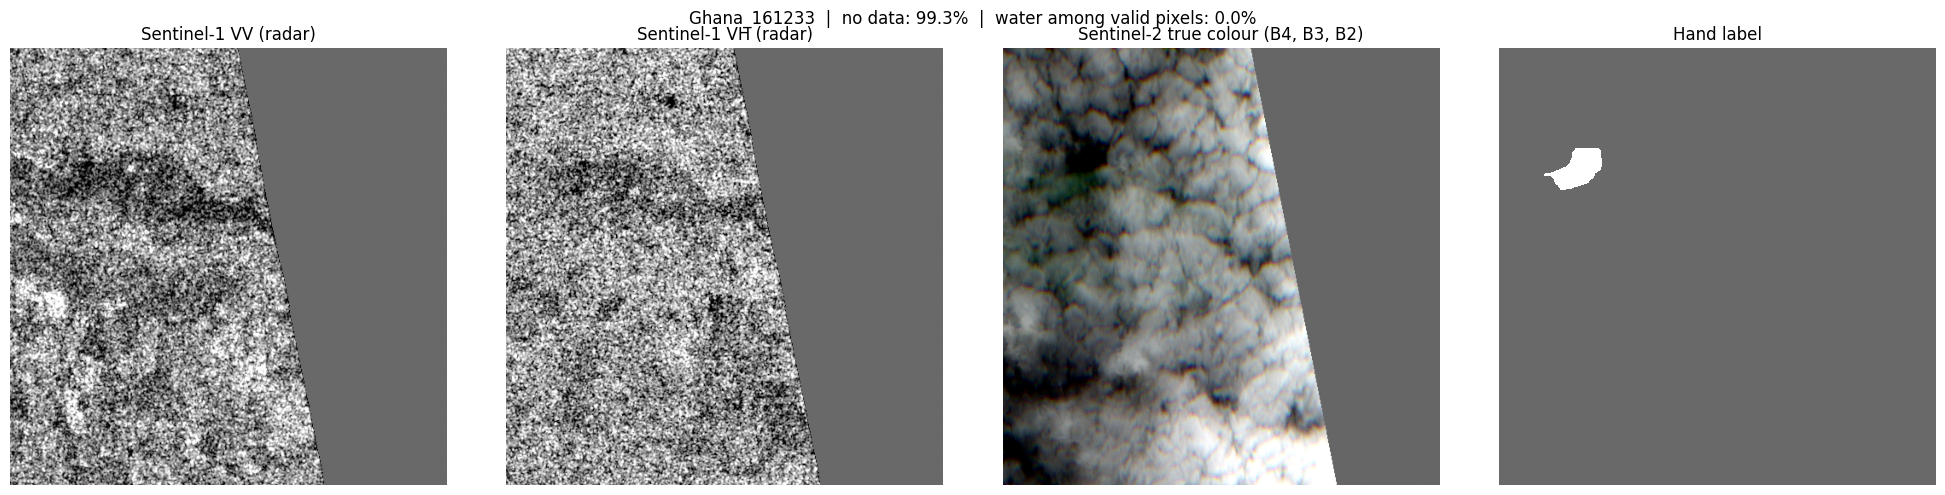

In [22]:
# Cell 7: Three contrasting chips selected from the label statistics
mostly_valid = stats[stats["nodata_pct"] < 20].sort_values("water_pct_of_valid")
has_valid = stats[stats["nodata_pct"] < 100].sort_values("nodata_pct")

picks = {
    "most water (under 20% no data)": mostly_valid.iloc[-1]["chip_id"],
    "least water (under 20% no data)": mostly_valid.iloc[0]["chip_id"],
    "most no data (some valid pixels left)": has_valid.iloc[-1]["chip_id"],
}

for reason, chip_id in picks.items():
    print(f"\n{reason}: {chip_id}")
    show_chip(chip_id)